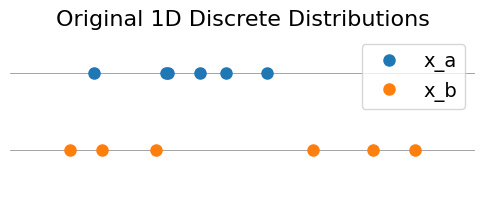

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from ot.partial import partial_wasserstein_1d


def plot_partial_transport(
    ax, x_a, x_b, indices_a=None, indices_b=None, marginal_costs=None
):
    y_a = np.ones_like(x_a)
    y_b = -np.ones_like(x_b)
    min_min = min(x_a.min(), x_b.min())
    max_max = max(x_a.max(), x_b.max())

    ax.plot([min_min - 1, max_max + 1], [1, 1], "k-", lw=0.5, alpha=0.5)
    ax.plot([min_min - 1, max_max + 1], [-1, -1], "k-", lw=0.5, alpha=0.5)

    # Plot transport lines
    if indices_a is not None and indices_b is not None:
        subset_a = np.sort(x_a[indices_a])
        subset_b = np.sort(x_b[indices_b])

        for x_a_i, x_b_j in zip(subset_a, subset_b):
            ax.plot([x_a_i, x_b_j], [1, -1], "k--", alpha=0.7)

    # Plot all points
    ax.plot(x_a, y_a, "o", color="C0", label="x_a", markersize=8)
    ax.plot(x_b, y_b, "o", color="C1", label="x_b", markersize=8)

    if marginal_costs is not None:
        k = len(marginal_costs)
        ax.set_title(
            f"Partial Transport - k = {k}, Cumulative Cost = {sum(marginal_costs):.2f}",
            fontsize=16,
        )
    else:
        ax.set_title("Original 1D Discrete Distributions", fontsize=16)
    ax.legend(loc="upper right", fontsize=14)
    ax.set_yticks([])
    ax.set_xticks([])
    ax.set_ylim(-2, 2)
    ax.set_xlim(min(x_a.min(), x_b.min()) - 1, max(x_a.max(), x_b.max()) + 1)
    ax.axis("off")


# Simulate two 1D discrete distributions
np.random.seed(0)
n = 6
x_a = np.sort(np.random.uniform(0, 10, size=n))
x_b = np.sort(np.random.uniform(0, 10, size=n))

# Plot original distributions
plt.figure(figsize=(6, 2))
plot_partial_transport(plt.gca(), x_a, x_b)
plt.show()

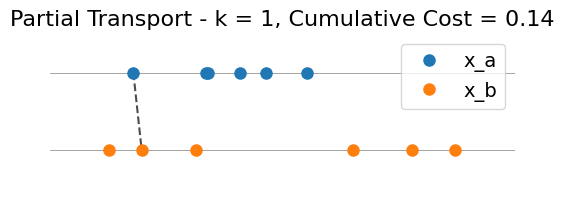

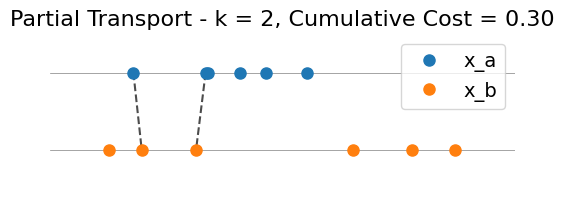

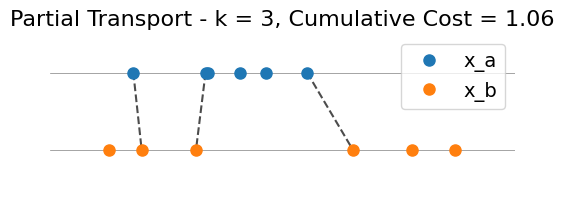

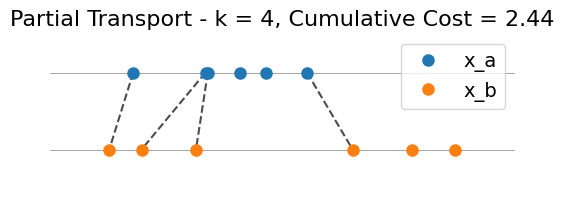

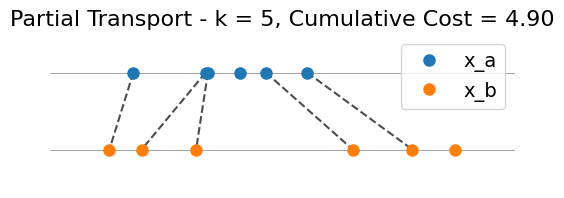

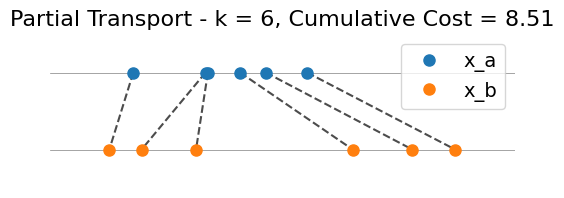

In [3]:
indices_a, indices_b, marginal_costs = partial_wasserstein_1d(x_a, x_b)

# Compute cumulative cost
cumulative_costs = np.cumsum(marginal_costs)

# Visualize all partial transport plans
for k in range(n):
    plt.figure(figsize=(6, 2))
    plot_partial_transport(
        plt.gca(),
        x_a,
        x_b,
        indices_a[: k + 1],
        indices_b[: k + 1],
        marginal_costs[: k + 1],
    )
    plt.show()